<a href="https://www.kaggle.com/code/mahdimashayekhi/smart-movie-recommendation?scriptVersionId=261273356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Smart Movie Recommender 🎬🍿

## Project Overview

### Description about the project...

## Importing neccessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

## Loading the datasets

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/movielens-20m-dataset/rating.csv
/kaggle/input/movielens-20m-dataset/link.csv
/kaggle/input/movielens-20m-dataset/genome_tags.csv
/kaggle/input/movielens-20m-dataset/genome_scores.csv
/kaggle/input/movielens-20m-dataset/tag.csv
/kaggle/input/movielens-20m-dataset/movie.csv


In [3]:
movies = pd.read_csv('/kaggle/input/movielens-20m-dataset/movie.csv')
ratings = pd.read_csv('/kaggle/input/movielens-20m-dataset/rating.csv')
links = pd.read_csv('/kaggle/input/movielens-20m-dataset/link.csv')
tags = pd.read_csv('/kaggle/input/movielens-20m-dataset/tag.csv')

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
print(f"Movies dataset has {movies.shape[0]} rows and {movies.shape[1]} columns.")

Movies dataset has 87585 rows and 3 columns.


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [9]:
print(f"Ratings dataset has {ratings.shape[0]} rows and {ratings.shape[1]} columns.")

Ratings dataset has 32000204 rows and 4 columns.


In [6]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [10]:
print(f"Links dataset has {links.shape[0]} rows and {links.shape[1]} columns.")

Links dataset has 87585 rows and 3 columns.


In [7]:
tags.head()

,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


In [11]:
print(f"Tags dataset has {tags.shape[0]} rows and {tags.shape[1]} columns.")

Tags dataset has 2000072 rows and 4 columns.


## Exploratory Data Analysis

In [23]:
datasets = [ratings, movies, links, tags]
dataset_names = ['Ratings', 'Movies', 'Links', 'Tags']

for i, dataset in enumerate(datasets):
    print(f"\n{dataset_names[i]} dataets:")
    dataset.info()
    print()


Ratings dataets:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


Movies dataets:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


Links dataets:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  87585 non-null  int64  
 1   imdbId   87585 non-null  int64  
 2   tmdbId   87461 non-null  floa

In [15]:
ratings.describe()

,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09


In [26]:
for i, dataset in enumerate(datasets):
    print(f"\n{dataset_names[i]} dataets:")
    print(dataset.isnull().sum())
    print()



Ratings dataets:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Movies dataets:
movieId    0
title      0
genres     0
dtype: int64


Links dataets:
movieId      0
imdbId       0
tmdbId     124
dtype: int64


Tags dataets:
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64



In [28]:
for i, dataset in enumerate(datasets):
    print(f"\n{dataset_names[i]} dataets:")
    print(f"Total number of missing values is {dataset.isnull().sum().sum()}")
    print()


Ratings dataets:
Total number of missing values is 0


Movies dataets:
Total number of missing values is 0


Links dataets:
Total number of missing values is 124


Tags dataets:
Total number of missing values is 17



In [30]:
# Datasets that have missing values: Links, Tags

In [29]:
for i, dataset in enumerate(datasets):
    print(f"\n{dataset_names[i]} dataets:")
    print(f"Total number of duplicated values is {dataset.duplicated().sum()}")
    print()


Ratings dataets:
Total number of duplicated values is 0


Movies dataets:
Total number of duplicated values is 0


Links dataets:
Total number of duplicated values is 0


Tags dataets:
Total number of duplicated values is 0



In [31]:
# Checking Ratings Dataset:

ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [39]:
# Users

print(f"Number of unique users: {ratings.userId.nunique()}")
print(f"Ratio of unique users per all {round((ratings.userId.nunique() / ratings.shape[0]) * 100, 2)}%")

Number of unique users: 200948
Ratio of unique users per all 0.63%


In [40]:
# Movies

print(f"Number of unique movies: {ratings.movieId.nunique()}")
print(f"Ratio of unique movies per all {round((ratings.movieId.nunique() / ratings.shape[0]) * 100, 2)}%")

Number of unique movies: 84432
Ratio of unique movies per all 0.26%


In [41]:
# Ratings

print(f"Number of unique ratings: {ratings.rating.nunique()}")
print(f"Ratio of unique ratings per all {round((ratings.rating.nunique() / ratings.shape[0]) * 100, 2)}%")

Number of unique ratings: 10
Ratio of unique ratings per all 0.0%


In [42]:
ratings.rating.value_counts()

rating
4.0    8367654
3.0    6054990
5.0    4596577
3.5    4290105
4.5    2974000
2.0    2028622
2.5    1685386
1.0     946675
1.5     531063
0.5     525132
Name: count, dtype: int64

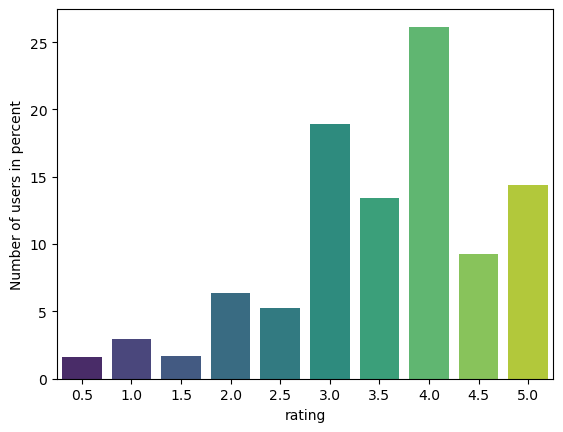

In [58]:
rating_counts = ratings['rating'].value_counts(normalize=True) * 100
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.ylabel('Number of users in percent')
plt.show()

In [44]:
num_ratings = ratings.shape[0]
print(num_ratings)

32000204


In [48]:
# Check the density of ratings

num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
density = num_ratings / (num_users * num_movies)
print(f"{round(density * 100, 2)}%")

0.19%


In [59]:
# Checking Movies Dataset:

In [63]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [62]:
print(f"Number of unique movies: {movies.movieId.nunique()}")

if movies.movieId.nunique() == movies.shape[0]:
    print("All movies are unique!")
else:
    print("Some movies are duplicated!")

Number of unique movies: 87585
All movies are unique!


In [64]:
print(f"Number of unique genres: {movies.genres.nunique()}")

Number of unique genres: 1798


In [66]:
genres_unq = movies.genres.unique()
genres_unq

array(['Adventure|Animation|Children|Comedy|Fantasy',
       'Adventure|Children|Fantasy', 'Comedy|Romance', ...,
       'Action|Animation|Children|Fantasy|Romance',
       'Adventure|Horror|Mystery|Sci-Fi',
       'Animation|Comedy|Crime|Drama|Romance|Sci-Fi'], dtype=object)

In [72]:
all_genres = movies['genres'].str.split('|')
flat_genres = [genre for sublist in all_genres for genre in sublist]
unique_genres = set(flat_genres)
print("Number of unique genres:", len(unique_genres))
print(unique_genres)

Number of unique genres: 20
{'Comedy', 'IMAX', 'Children', 'Adventure', 'Musical', 'Drama', '(no genres listed)', 'Horror', 'War', 'Sci-Fi', 'Thriller', 'Fantasy', 'Western', 'Mystery', 'Documentary', 'Action', 'Crime', 'Film-Noir', 'Animation', 'Romance'}


In [75]:
genre_counts = Counter(flat_genres)
genre_counts

Counter({'Drama': 34175,
         'Comedy': 23124,
         'Thriller': 11823,
         'Romance': 10369,
         'Action': 9668,
         'Documentary': 9363,
         'Horror': 8654,
         '(no genres listed)': 7080,
         'Crime': 6976,
         'Adventure': 5402,
         'Sci-Fi': 4907,
         'Animation': 4617,
         'Children': 4520,
         'Mystery': 4013,
         'Fantasy': 3851,
         'War': 2325,
         'Western': 1696,
         'Musical': 1059,
         'Film-Noir': 353,
         'IMAX': 195})

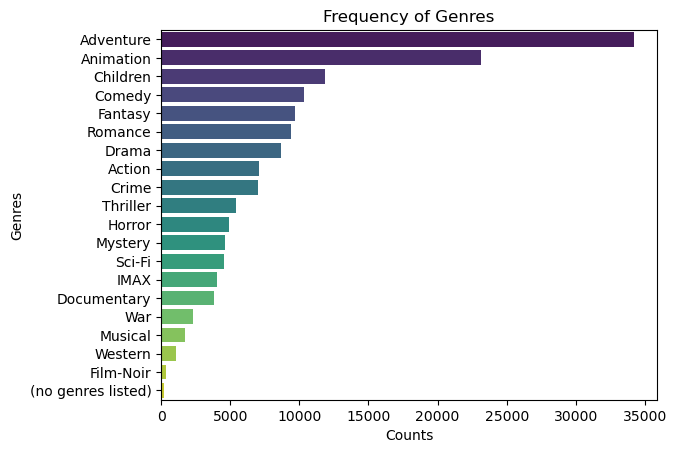

In [100]:
sns.barplot(x=sorted(genre_counts.values(), reverse=True), y=genre_counts.keys(), palette='viridis')
plt.title('Frequency of Genres')
plt.xlabel('Counts')
plt.ylabel('Genres')
plt.show()

In [98]:
# Movies with no ratings

movies_with_ratings = movies.merge(ratings, on='movieId', how='left')

no_ratings = movies_with_ratings[movies_with_ratings['rating'].isna()]
no_ratings.head()

,movieId,title,genres,userId,rating,timestamp
24845432,52696,"Thousand and One Nights, A (1001 Nights) (1945)",Adventure,NaN,NaN,NaN
25485425,58209,Alex in Wonder (Sex and a Girl) (2001),Comedy|Drama,NaN,NaN,NaN
26506533,69864,Blue Blood (2006),Documentary,NaN,NaN,NaN
26547568,70312,"Family Secret, A (Le secret de ma mère) (2006)",Comedy|Drama|Musical,NaN,NaN,NaN
26599184,71355,February (Khumphaphan) (2003),Drama|Romance,NaN,NaN,NaN


In [99]:
print("Nubmer of movies with no ratings:", no_ratings.shape[0])

Nubmer of movies with no ratings: 3153


In [101]:
# Checking Tags Dataset:

tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')

In [103]:
print(f"Count of unique users that have tags: {tags.userId.nunique()} / {tags.shape[0]}")

Count of unique users that have tags: 15848 / 2000072


In [104]:
print(f"Count of unique movies that have tags: {tags.movieId.nunique()} / {tags.shape[0]}")

Count of unique movies that have tags: 51323 / 2000072


In [105]:
print(f"Count of all unique tags: {tags.tag.nunique()}")

Count of all unique tags: 140979


In [111]:
tag_counts = tags.tag.value_counts()
top_tag_counts = tag_counts[tag_counts > 5000]
top_tag_counts

tag
sci-fi                10996
atmospheric            9589
action                 8473
comedy                 8139
funny                  7467
surreal                7231
visually appealing     7090
based on a book        6617
twist ending           6521
dark comedy            6053
thought-provoking      6000
dystopia               5646
violence               5389
cinematography         5277
romance                5271
murder                 5180
social commentary      5152
Name: count, dtype: int64

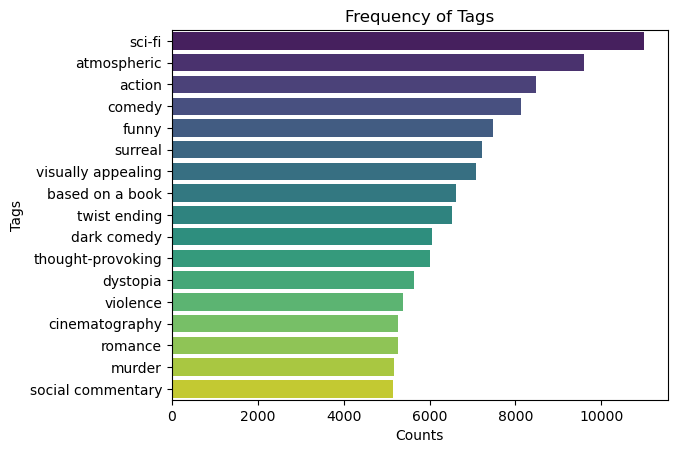

In [119]:
sns.barplot(x=sorted(top_tag_counts.values, reverse=True), y=top_tag_counts.index, palette='viridis')
plt.title('Frequency of Tags')
plt.xlabel('Counts')
plt.ylabel('Tags')
plt.show()

In [120]:
# Movies with no tags

movies_with_tags = movies.merge(tags, on='movieId', how='left')

no_ratings = movies_with_tags[movies_with_tags['tag'].isna()]
no_ratings.head()

,movieId,title,genres,userId,tag,timestamp
16412,51,Guardian Angel (1994),Action|Drama|Thriller,NaN,NaN,NaN
16453,56,Kids of the Round Table (1995),Adventure|Children|Comedy|Fantasy,NaN,NaN,NaN
18545,84,Last Summer in the Hamptons (1995),Comedy|Drama,NaN,NaN,NaN
18741,90,The Journey of August King (1995),Drama,NaN,NaN,NaN
20209,108,Catwalk (1996),Documentary,NaN,NaN,NaN


In [121]:
print("Nubmer of movies with no tags:", no_ratings.shape[0])

Nubmer of movies with no tags: 36279


In [122]:
# Checking Links Dataset:

links.columns

Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')

In [124]:
print(f"Number of unique movies in links: {links.movieId.nunique()}")

Number of unique movies in links: 87585


In [125]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [132]:
# Who gave the most comments for movies?

user_frequently = ratings[['userId', 'movieId']].groupby('userId').count().reset_index()
user_frequently.columns = ['userId', 'n_ratings']
user_frequently.sort_values(by='n_ratings', ascending=False).head()

,userId,n_ratings
175324,175325,33332
17034,17035,9577
55652,55653,9178
123464,123465,9044
171794,171795,9016
